In [11]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [12]:
def subplot_align(axis1, *axes, dim='x'):
    """
    Aligns the position of the given primary axis (axis1) with other specified axes based on the specified dimension.

    This function adjusts the position of the primary axis `axis1` to align with the other given axes along the specified dimension ('x', 'y', or 'both'). It listens for resize events on the figure canvas and dynamically adjusts the position of `axis1` to maintain alignment.

    Parameters:
    axis1 (matplotlib.axes.Axes): The primary axis whose position will be adjusted.
    *axes (matplotlib.axes.Axes): Additional axes to which the primary axis should be aligned.
    dim (str): The dimension along which to align the axes. Must be one of 'x', 'y', or 'both'. Default is 'x'.

    Raises:
    ArgumentError: If the specified dimension is not 'x', 'y', or 'both'.

    Returns:
    None

    Example:
    --------
    >>> fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
    >>> subplot_align(ax1, ax2, ax3, dim='y')
    
    This will align `ax1` with `ax2` and `ax3` along the y-axis.
    """
    
    # Check if the specified dimension is valid
    if not dim.lower() in ['x', 'y', 'both']:
        raise ArgumentError(f'dimension to align is not understood. You chose: {dim}. Please specify either "x" or "y" or "both".')
    
    def onresize(axis1, axes, event):
        """
        Inner function to handle the resize event by adjusting the position of axis1.
        """
        if dim.lower() == 'x':
            # Concatenate all x-axis positions of the specified axes
            x = np.concatenate([[ax.get_position().x0, ax.get_position().x1] for ax in axes])
            # Calculate the new width and x-position for axis1
            width = max(x) - min(x)
            x = min(x)
            y = axis1.get_position().y0
            height = axis1.get_position().height
        elif dim.lower() == 'y':
            # Concatenate all y-axis positions of the specified axes
            y = np.concatenate([[ax.get_position().y0, ax.get_position().y1] for ax in axes])
            # Calculate the new height and y-position for axis1
            height = max(y) - min(y)
            y = min(y)
            x = axis1.get_position().x0
            width = axis1.get_position().width
        elif dim.lower() == 'both':
            # Concatenate all x and y positions of the specified axes
            x = np.concatenate([[ax.get_position().x0, ax.get_position().x1] for ax in axes])
            width = max(x) - min(x)
            x = min(x)
            y = np.concatenate([[ax.get_position().y0, ax.get_position().y1] for ax in axes])
            height = max(y) - min(y)
            y = min(y)
        # Set the new position of axis1
        return axis1.set_position([x, y, width, height])
    
    import functools
    # Create a partial function that binds the axes and the onresize function
    onresize_wrapper = functools.partial(onresize, axis1, axes)
    # Connect the resize event of the figure to the onresize_wrapper function
    cid = axis1.figure.canvas.mpl_connect('resize_event', onresize_wrapper)
    
    # Initially align the axis1 with the specified axes
    return onresize(axis1, axes, None)

In [13]:
joined_lfes_fp = '../data/calculated/Joined_LFEs_w_phases.csv'

# Import lfe data and clear nans
lfes = pd.read_csv(joined_lfes_fp, usecols=['start', 'end', 'duration', 'subLST', 'subLat', 'R_ksm', 'x_ksm', 'y_ksm', 'z_ksm', 'north phase', 'south phase'])
lfes = lfes.dropna().reset_index(drop=True)

# Sort data in north/south bins
phase_bins = np.arange(0, 390, 30)
lfes['north_bins'] = pd.cut(lfes['north phase'] % 360, bins=phase_bins)
lfes['south_bins'] = pd.cut(lfes['south phase'] % 360, bins=phase_bins)
#lfes

#Calculate local phases
north= np.array(lfes['north phase']) %360
south= np.array(lfes['south phase']) %360

azimuth=[]
for lt in lfes['subLST']:
    azimuth.append(((lt-12) * 15 + 720) % 360)
    
north_phase_local = []
south_phase_local = []
for north_phase, south_phase, az in zip(north, south, azimuth):
    north_phase_local.append(((north_phase - az) + 720) % 360)
    south_phase_local.append(((south_phase - az) + 720) % 360)

north_phase_local = np.array(north_phase_local)
south_phase_local = np.array(south_phase_local)

    # Append local phases to dataframe
lfes['north phase local'] = north_phase_local
lfes['south phase local'] = south_phase_local

# Sort data in north/south LOCAL bins
phase_bins_local = np.arange(0, 390, 30)
lfes['north_bins_local'] = pd.cut(lfes['north phase local'] % 360, bins=phase_bins_local)
lfes['south_bins_local'] = pd.cut(lfes['south phase local'] % 360, bins=phase_bins_local)


In [14]:
#def select_lfes(lfes, subLST_cond=(lfes['subLST'].min(), lfes['subLST'].max()), duration_cond=(lfes['duration'].min(), lfes['duration'].max()), subLat_cond=(lfes['subLat'].min(), lfes['subLat'].max())):
def select_lfes(lfes, subLST_cond=None, duration_cond=None, subLat_cond=None):

    selected_lfes=lfes.copy()
    
    filter_by_subLST=False
    filter_by_duration=False
    filter_by_subLaT=False
    
    if subLST_cond is not None:
        filter_by_subLST=True
        
    if duration_cond is not None:
        filter_by_duration=True

    if subLat_cond is not None:
        filter_by_subLat=True

    if filter_by_duration is True:
        duration_min, duration_max = duration_cond
        selected_lfes = selected_lfes[(duration_min <= selected_lfes['duration']) & (selected_lfes['duration'] < duration_max)]

    if filter_by_subLST is True:
        subLST_min, subLST_max = subLST_cond
        if subLST_max < subLST_min:  #over midnight boundary
            selected_lfes = selected_lfes[(subLST_min <= selected_lfes['subLST']) | (selected_lfes['subLST'] < subLST_max)]  #or statement
        else:
            selected_lfes = selected_lfes[(subLST_min <= selected_lfes['subLST']) & (selected_lfes['subLST'] < subLST_max)]
        
#    subLST_min, subLST_max = subLST_cond
#    duration_min, duration_max = duration_cond
#    subLat_min, subLat_max = subLat_cond

  #  selected_lfes = lfes[(duration_min < lfes['duration']) & (lfes['duration'] <= duration_max)]
    
    #selected_lfes = lfes[(subLST_min <= lfes['subLST']) & (lfes['subLST'] <= subLST_max) & (duration_min <= lfes['duration']) & (lfes['duration'] <= duration_max) & (subLat_min <= lfes['subLat']) & (lfes['subLat'] <= subLat_max)]
    #selected_lfes = lfes[(subLST_min <= lfes['subLST']) & (lfes['subLST'] <= subLST_max) & (duration_min <= lfes['duration']) & (lfes['duration'] < duration_max) & (subLat_min <= lfes['subLat']) & (lfes['subLat'] <= subLat_max)]

    print(lfes['subLST'].min())
    print(lfes['subLST'].max())
    print(lfes['duration'].min())
    print(lfes['duration'].max())
    
    return selected_lfes

# Select here which LFEs you want to plot
Note: You have to provide both lower and upper bound limits if you want to use a condition.

In [15]:
#selected_lfes = lfes # All LFEs

#selected_lfes = select_lfes(lfes, duration_cond=(lfes['duration'].min(), 11*3600)) # Short duration LFEs
selected_lfes = select_lfes(lfes, duration_cond=(11*3600,lfes['duration'].max()+1)) # Long duration LFEs

#selected_lfes = select_lfes(lfes, subLST_cond=(3, 9)) # LFEs at dawn
#selected_lfes = select_lfes(lfes, subLST_cond=(15, 21)) # LFEs at dusk
#selected_lfes = select_lfes(lfes, subLST_cond=(9, 15)) # LFEs at noon
#selected_lfes = select_lfes(lfes, subLST_cond=(21, 3)) # LFEs at midnight

#selected_lfes = select_lfes(lfes, subLST_cond=(3, 9), duration_cond=(lfes['duration'].min(), 11*3600)) # Short LFEs at dawn
#selected_lfes = select_lfes(lfes, subLST_cond=(3, 9), duration_cond=(11*3600,lfes['duration'].max()+1)) # Long LFEs at dawn

#####cmj to fix from below
#selected_lfes = select_lfes(lfes, subLST_cond=(3, 9), duration_cond=(lfes['duration'].min(), 11*3600)) # Short LFEs at dusk
#selected_lfes = select_lfes(lfes, subLST_cond=(3, 9), duration_cond=(11*3600,lfes['duration'].max()+1)) # Long LFEs at dusk


#old calls below


#selected_lfes = select_lfes(lfes, subLat_cond=(lfes['subLat'].min(), -11)) # LFEs seen from southern latitude
#selected_lfes = select_lfes(lfes, subLat_cond=(11, lfes['subLat'].max())) # LFEs seen from northern latitude

#selected_lfes = select_lfes(lfes, subLST_cond=(15, 21), subLat_cond=(lfes['subLat'].min(), -11)) # LFEs at dusk in the southern latitudes
#selected_lfes = select_lfes(lfes, subLST_cond=(15, 21), duration_cond=(lfes['duration'].min(), 11*3600)) # Short LFEs at dusk
#selected_lfes = select_lfes(lfes, subLST_cond=(15, 21), duration_cond=(11*3600, lfes['duration'].max())) # Long LFEs at dusk
#selected_lfes = select_lfes(lfes, subLST_cond=(9, 15), duration_cond=(lfes['duration'].min(), 11*3600)) # Short LFEs at noon
#selected_lfes = select_lfes(lfes, subLST_cond=(9, 15), duration_cond=(11*3600, lfes['duration'].max())) # Long LFEs at noon


#pre_midnight_short_lfes = select_lfes(lfes, subLST_cond=(21, 24), duration_cond=(lfes['duration'].min(), 11*3600))
#post_midnight_short_lfes = select_lfes(lfes, subLST_cond=(0, 3), duration_cond=(lfes['duration'].min(), 11*3600))
#selected_lfes = pd.concat([pre_midnight_short_lfes,post_midnight_short_lfes]) # Short LFEs at midnight
#selected_lfes = selected_lfes.sort_values(by=["start"])   #to amend for any issues around midnight

#pre_midnight_long_lfes = select_lfes(lfes, subLST_cond=(21, 24), duration_cond=(11*3600, lfes['duration'].max()))
#post_midnight_long_lfes = select_lfes(lfes, subLST_cond=(0, 3), duration_cond=(11*3600, lfes['duration'].max()))
#selected_lfes = pd.concat([pre_midnight_long_lfes,post_midnight_long_lfes]) # Long LFEs at midnight

print(selected_lfes)


0.0005555555555555
23.9875
1800.0
442620.0
                        start                      end       x_ksm  \
54    2004-02-06 07:27:00.000  2004-02-07 02:33:00.000  513.342243   
62    2004-02-21 01:30:00.000  2004-02-21 23:03:00.000  455.198516   
79    2004-03-05 13:15:00.000  2004-03-06 18:42:00.000  403.686280   
110   2004-03-21 16:39:00.000  2004-03-22 10:27:00.000  344.101444   
113   2004-03-23 03:36:00.000  2004-03-23 19:57:00.000  338.833008   
...                       ...                      ...         ...   
4419  2017-07-20 19:39:00.000  2017-07-21 11:06:00.000  -15.671579   
4424  2017-08-13 09:24:00.000  2017-08-14 03:33:00.000   -7.206981   
4425  2017-08-14 04:57:00.000  2017-08-14 18:57:00.000    0.126504   
4430  2017-08-21 01:24:00.000  2017-08-21 15:21:00.000   -7.658752   
4434  2017-09-07 12:18:00.000  2017-09-08 10:24:00.000  -11.991286   

            y_ksm       z_ksm        R_ksm     subLST     subLat  duration  \
54   -1049.074071 -121.777248  1174.26

In [16]:
#For global phases
# Find the amount of lfe counts by phase in 2d north/south bins, and 1D south / 1D north bins
phase_counts = selected_lfes.groupby(['north_bins', 'south_bins']).size()
n_counts = selected_lfes.groupby('north_bins').size().to_numpy()
s_counts = selected_lfes.groupby('south_bins').size().to_numpy()

# Create the lfe count map by phase ready to be plotted
phase_map = phase_counts.to_numpy().reshape((len(phase_bins)-1,len(phase_bins)-1))


#Repeat for local phases
# Find the amount of lfe counts by phase in 2d north/south bins, and 1D south / 1D north bins
phase_counts_local = selected_lfes.groupby(['north_bins_local', 'south_bins_local']).size()
n_counts_local = selected_lfes.groupby('north_bins_local').size().to_numpy()
s_counts_local = selected_lfes.groupby('south_bins_local').size().to_numpy()

# Create the lfe count map by phase ready to be plotted
phase_map_local = phase_counts_local.to_numpy().reshape((len(phase_bins_local)-1,len(phase_bins_local)-1))

C:\Users\Local Admin\AppData\Local\Temp\ipykernel_12408\404636789.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_counts = selected_lfes.groupby(['north_bins', 'south_bins']).size()
C:\Users\Local Admin\AppData\Local\Temp\ipykernel_12408\404636789.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_counts = selected_lfes.groupby('north_bins').size().to_numpy()
C:\Users\Local Admin\AppData\Local\Temp\ipykernel_12408\404636789.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or o

[ 15  45  75 105 135 165 195 225 255 285 315 345]


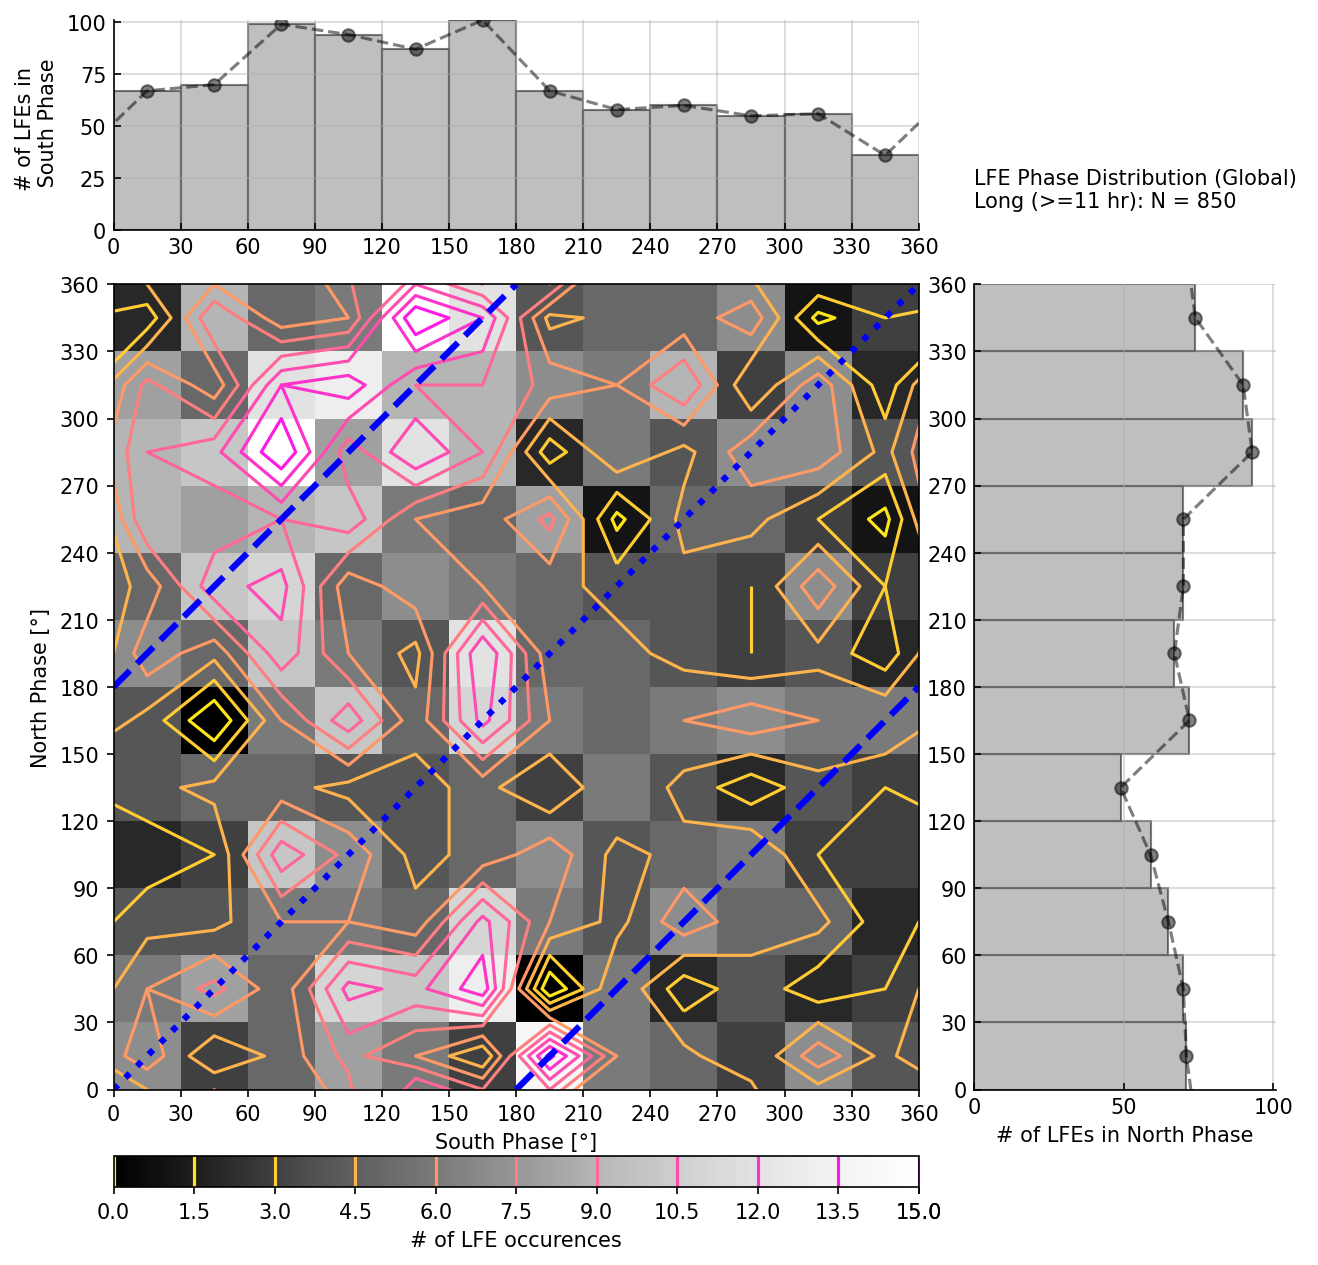

In [17]:
#Global Phases Plot

# North South Distribution Plot
big_map = np.tile(phase_map, (3,3)) #  Have to create this otherwise the lines do not start at the edges
big_centers = np.arange(-360, 720, 30) + 15  # Centers for the map above
centers = phase_bins[:-1] + 15  # Centers for the regular colormap

# Levels Number
if phase_map.max() < 10:
    levels = phase_map.max()
else:
    levels = 10

# Limits of histograms
xlim1, xlim2 = 0, 360
ylim1, ylim2 = 0, np.max(np.hstack((n_counts, s_counts)))

# Figure
fig = plt.figure(figsize=(10,10), dpi=150)
gs = fig.add_gridspec(3, 2, height_ratios=[1, 4, 0.15], width_ratios=[2, 0.75], wspace=0.1, hspace=0.1)

# Title
axt = fig.add_subplot(gs[1])
axt.axis('off')
axt.annotate(f"LFE Phase Distribution (Global) \n"
             #f"All: N = {phase_map.sum()} \n", (0,0))
             #f"Short (<11 hr): N = {phase_map.sum()} \n", (0,0))
             f"Long (>=11 hr): N = {phase_map.sum()} \n", (0,0))
             #f"Long (> 11 hr): N = {phase_map.sum()} \n", (0,0))
#             f"All, Dawn 03-09: N = {phase_map.sum()} \n", (0,0))
             #f"All, Dusk 15-21: N = {phase_map.sum()} \n", (0,0))
             #f"All, Noon 09-15: N = {phase_map.sum()} \n", (0,0))
             #f"All, Midnight 21-03: N = {phase_map.sum()} \n", (0,0))

            #f"Long (> 11 hr), Dawn 3-9: N = {phase_map.sum()} \n", (0,0))
            #f"Short (< 11 hr), Dusk 15-21: N = {phase_map.sum()} \n", (0,0))
            #f"Long (> 11 hr), Dusk 15-21: N = {phase_map.sum()} \n", (0,0))
            #f"Short (< 11 hr), Noon 09-15: N = {phase_map.sum()} \n", (0,0))
            #f"Long (> 11 hr), Noon 09-15: N = {phase_map.sum()} \n", (0,0))
            #f"Short (< 11 hr), Midnight 21-03: N = {phase_map.sum()} \n", (0,0))
            #f"Long (> 11 hr), Midnight 21-03: N = {phase_map.sum()} \n", (0,0))



# LFE Phase Distribution
ax = fig.add_subplot(gs[2])

distr = ax.pcolormesh(phase_bins, phase_bins, phase_map, cmap='Greys_r')  # Colormap
ctr = ax.contour(big_centers, big_centers, big_map, levels=levels, cmap='spring_r')  # Contour plot
ax.set_aspect('equal')

ax.set_xlim(xlim1, xlim2)
ax.set_ylim(xlim1, xlim2)
ax.set_xticks(phase_bins)
ax.set_yticks(phase_bins)
ax.set_yticklabels(phase_bins)
ax.set_xlabel('South Phase [°]')
ax.set_ylabel('North Phase [°]')

# Colour Bar
ax_cbar = fig.add_subplot(gs[4])
cbar = fig.colorbar(distr, cax=ax_cbar, label='# of LFE occurences', orientation='horizontal', ticks=np.hstack((ctr.levels, phase_map.max())))
cbar.add_lines(ctr)
pos = ax_cbar.get_position()
ax_cbar.set_position([pos.x0, pos.y0-.008, pos.width, pos.height])

# South Phase Distribution
axs = fig.add_subplot(gs[0])
axs.bar(centers, s_counts, width=30, edgecolor='black', align='center', facecolor='grey', alpha=0.5, label='# LFEs in South Phase')
#axs.plot(centers, s_counts, 'o--', color='black', alpha=0.5)
print(centers)
axs.plot([-15]+centers.tolist()+[375], [s_counts[-1]]+s_counts.tolist()+[s_counts[0]], 'o--', color='black', alpha=0.5)
#print([-15]+centers+[375])

axs.set_xticks(phase_bins)
axs.tick_params(axis="x", direction="in")
axs.tick_params(axis="y", direction="in")
axs.spines[['right', 'top']].set_visible(False)
axs.set_ylim(ylim1, ylim2)
axs.set_xlim(xlim1, xlim2)
axs.set_ylabel('# of LFEs in \n South Phase')
axs.grid(alpha=0.5)

# North Phase Distribution
axn = fig.add_subplot(gs[3])
axn.barh(centers, n_counts, height=30, edgecolor='black', align='center', facecolor='grey', alpha=0.5, label='#LFEs in North Phase')
#axn.plot(n_counts, centers, 'o--', color='black', alpha=0.5)
#axn.plot(n_counts, centers, 'o--', color='black', alpha=0.5)
axn.plot([n_counts[-1]]+n_counts.tolist()+[n_counts[0]],[-15]+centers.tolist()+[375], 'o--', color='black', alpha=0.5)
#print(centers)


axn.set_yticks(phase_bins)
axn.tick_params(axis="x", direction="in")
axn.tick_params(axis="y", direction="in")
axn.spines[['right', 'top']].set_visible(False)
axn.set_ylim(xlim1, xlim2)
axn.set_xlim(ylim1, ylim2)
axn.set_xlabel('# of LFEs in North Phase')
axn.grid(alpha=0.5)

# Adjust Positon
axs.sharex(ax)
axn.sharey(ax)

subplot_align(ax_cbar, ax, dim='x')
subplot_align(axn, ax, dim='y')
subplot_align(axs, ax, dim='x')
#plt.tight_layout()

#ax3= fig.add_subplot()
#ax3.axvline(45, linestyle='--', color='blue')
#ax3.axhline(45, linestyle='--', color='blue')

ax.plot([0,360], [0,360], linestyle='dotted', color='blue',linewidth=3)
ax.plot([180,360], [0,180], linestyle='--', color='blue',linewidth=3)
ax.plot([0,180], [180,360], linestyle='--', color='blue',linewidth=3)


#plt.savefig("LFE_PPO_all_global.pdf",format="pdf")
#plt.savefig("LFE_PPO_dawn_global.pdf",format="pdf")
#plt.savefig("LFE_PPO_dusk_global.pdf",format="pdf")
#plt.savefig("LFE_PPO_noon_global.pdf",format="pdf")
#plt.savefig("LFE_PPO_midnight_global.pdf",format="pdf")

#plt.savefig("LFE_PPO_all_short_global.pdf",format="pdf")
plt.savefig("LFE_PPO_all_long_global.pdf",format="pdf")
#plt.savefig("LFE_PPO_short_dawn_global.pdf",format="pdf")
#plt.savefig("LFE_PPO_long_dawn_global.pdf",format="pdf")
#plt.savefig("LFE_PPO_short_dusk_global.pdf",format="pdf")
#plt.savefig("LFE_PPO_long_dusk_global.pdf",format="pdf")
#plt.savefig("LFE_PPO_short_noon_global.pdf",format="pdf")
#plt.savefig("LFE_PPO_long_midnight_global.pdf",format="pdf")


plt.show()

[ 15  45  75 105 135 165 195 225 255 285 315 345]


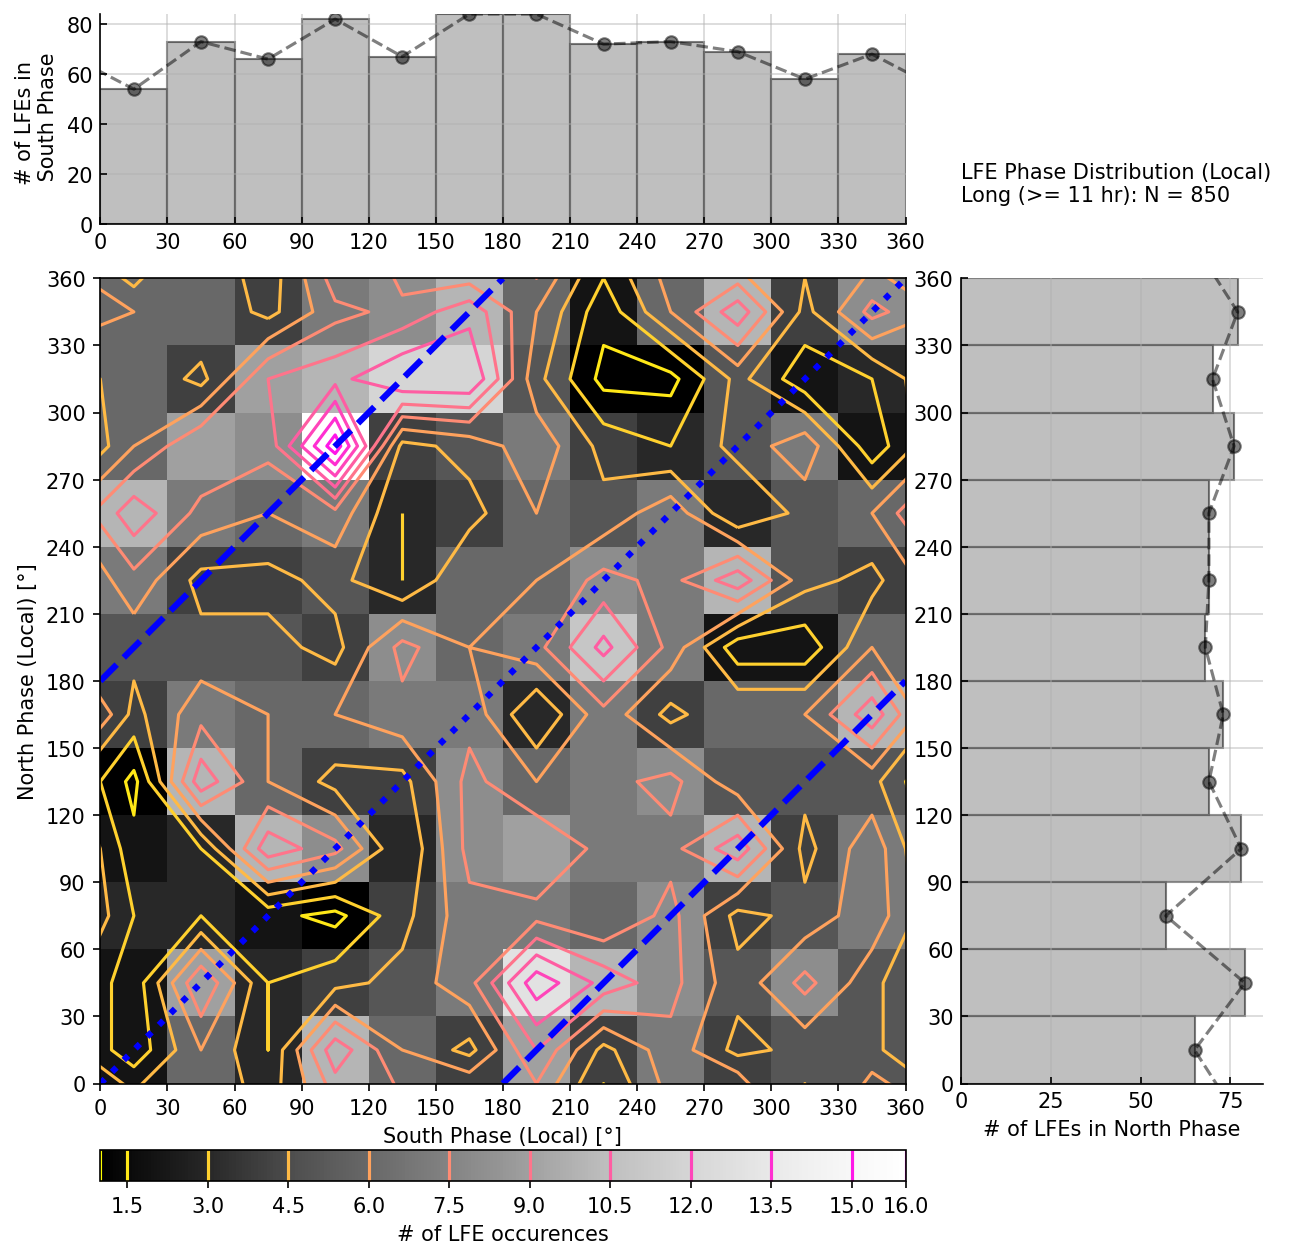

In [18]:
#Local Phases Plot

# North South Distribution Plot
big_map_local = np.tile(phase_map_local, (3,3)) #  Have to create this otherwise the lines do not start at the edges
big_centers_local = np.arange(-360, 720, 30) + 15  # Centers for the map above
centers_local = phase_bins_local[:-1] + 15  # Centers for the regular colormap

# Levels Number
if phase_map_local.max() < 10:
    levels_local = phase_map_local.max()
else:
    levels_local = 10

# Limits of histograms
xlim1, xlim2 = 0, 360
ylim1, ylim2 = 0, np.max(np.hstack((n_counts_local, s_counts_local)))

# Figure
fig = plt.figure(figsize=(10,10), dpi=150)
gs = fig.add_gridspec(3, 2, height_ratios=[1, 4, 0.15], width_ratios=[2, 0.75], wspace=0.1, hspace=0.1)

# Title
axt = fig.add_subplot(gs[1])
axt.axis('off')
axt.annotate(f"LFE Phase Distribution (Local) \n"
             #f"All: N = {phase_map_local.sum()} \n", (0,0))
#             f"All, Dawn 03-09: N = {phase_map_local.sum()} \n", (0,0))
             #f"All, Dusk 15-21: N = {phase_map_local.sum()} \n", (0,0))
             #f"All, Noon 09-15: N = {phase_map_local.sum()} \n", (0,0))
             #f"All, Midnight 21-03: N = {phase_map_local.sum()} \n", (0,0))

             #f"Short (<11 hr): N = {phase_map_local.sum()} \n", (0,0))
             f"Long (>= 11 hr): N = {phase_map_local.sum()} \n", (0,0))
             #f"Long (> 11 hr): N = {phase_map_local.sum()} \n", (0,0))
    #        f"Short (< 11 hr), Dawn 3-9: N = {phase_map_local.sum()} \n", (0,0))
            #f"Long (> 11 hr), Dawn 3-9: N = {phase_map_local.sum()} \n", (0,0))
            #f"Short (< 11 hr), Dusk 15-21: N = {phase_map_local.sum()} \n", (0,0))
            #f"Long (> 11 hr), Dusk 15-21: N = {phase_map_local.sum()} \n", (0,0))
            #f"Short (< 11 hr), Noon 09-15: N = {phase_map_local.sum()} \n", (0,0))
            #f"Long (> 11 hr), Noon 09-15: N = {phase_map_local.sum()} \n", (0,0))
            #f"Short (< 11 hr), Midnight 21-03: N = {phase_map_local.sum()} \n", (0,0))
            #f"Long (> 11 hr), Midnight 21-03: N = {phase_map_local.sum()} \n", (0,0))



# LFE Phase Distribution
ax = fig.add_subplot(gs[2])

distr = ax.pcolormesh(phase_bins_local, phase_bins_local, phase_map_local, cmap='Greys_r')  # Colormap
ctr = ax.contour(big_centers_local, big_centers_local, big_map_local, levels=levels_local, cmap='spring_r')  # Contour plot
ax.set_aspect('equal')

ax.set_xlim(xlim1, xlim2)
ax.set_ylim(xlim1, xlim2)
ax.set_xticks(phase_bins_local)
ax.set_yticks(phase_bins_local)
ax.set_yticklabels(phase_bins_local)
ax.set_xlabel('South Phase (Local) [°]')
ax.set_ylabel('North Phase (Local) [°]')

# Colour Bar
ax_cbar = fig.add_subplot(gs[4])
cbar = fig.colorbar(distr, cax=ax_cbar, label='# of LFE occurences', orientation='horizontal', ticks=np.hstack((ctr.levels, phase_map_local.max())))
cbar.add_lines(ctr)
pos = ax_cbar.get_position()
ax_cbar.set_position([pos.x0, pos.y0-.008, pos.width, pos.height])

# South Phase Distribution
axs = fig.add_subplot(gs[0])
axs.bar(centers_local, s_counts_local, width=30, edgecolor='black', align='center', facecolor='grey', alpha=0.5, label='# LFEs in South Phase')
print(centers_local)
axs.plot([-15]+centers_local.tolist()+[375], [s_counts_local[-1]]+s_counts_local.tolist()+[s_counts_local[0]], 'o--', color='black', alpha=0.5)

axs.set_xticks(phase_bins_local)
axs.tick_params(axis="x", direction="in")
axs.tick_params(axis="y", direction="in")
axs.spines[['right', 'top']].set_visible(False)
axs.set_ylim(ylim1, ylim2)
axs.set_xlim(xlim1, xlim2)
axs.set_ylabel('# of LFEs in \n South Phase')
axs.grid(alpha=0.5)

# North Phase Distribution
axn = fig.add_subplot(gs[3])
axn.barh(centers_local, n_counts_local, height=30, edgecolor='black', align='center', facecolor='grey', alpha=0.5, label='#LFEs in North Phase')
axn.plot([n_counts_local[-1]]+n_counts_local.tolist()+[n_counts_local[0]],[-15]+centers_local.tolist()+[375], 'o--', color='black', alpha=0.5)


axn.set_yticks(phase_bins_local)
axn.tick_params(axis="x", direction="in")
axn.tick_params(axis="y", direction="in")
axn.spines[['right', 'top']].set_visible(False)
axn.set_ylim(xlim1, xlim2)
axn.set_xlim(ylim1, ylim2)
axn.set_xlabel('# of LFEs in North Phase')
axn.grid(alpha=0.5)

# Adjust Positon
axs.sharex(ax)
axn.sharey(ax)

subplot_align(ax_cbar, ax, dim='x')
subplot_align(axn, ax, dim='y')
subplot_align(axs, ax, dim='x')

ax.plot([0,360], [0,360], linestyle='dotted', color='blue',linewidth=3)
ax.plot([180,360], [0,180], linestyle='--', color='blue',linewidth=3)
ax.plot([0,180], [180,360], linestyle='--', color='blue',linewidth=3)


#plt.savefig("LFE_PPO_all_local.pdf",format="pdf")
#plt.savefig("LFE_PPO_dawn_local.pdf",format="pdf")
#plt.savefig("LFE_PPO_dusk_local.pdf",format="pdf")
#plt.savefig("LFE_PPO_noon_local.pdf",format="pdf")
#plt.savefig("LFE_PPO_midnight_local.pdf",format="pdf")

#plt.savefig("LFE_PPO_all_short_local.pdf",format="pdf")
plt.savefig("LFE_PPO_all_long_local.pdf",format="pdf")
#plt.savefig("LFE_PPO_short_dawn_local.pdf",format="pdf")
#plt.savefig("LFE_PPO_long_dawn_local.pdf",format="pdf")
#plt.savefig("LFE_PPO_short_dusk_local.pdf",format="pdf")
#plt.savefig("LFE_PPO_long_dusk_local.pdf",format="pdf")
#plt.savefig("LFE_PPO_short_noon_local.pdf",format="pdf")
#plt.savefig("LFE_PPO_long_midnight_local.pdf",format="pdf")


plt.show()